### Loading

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df= pd.read_csv("../data/processed/upl_goals_2019_2025_cleaned.csv")

In [3]:
# df.head()
# df.shape
# df.info()
# df.describe()
# df.isna().sum()

### Preprocessing

In [4]:
# normalize column names: strip whitespace, lowercase, replace spaces (and other whitespace) with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(r'\s+', '_', regex=True)

In [5]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d', errors='coerce') # parse ISO-format dates (YYYY-MM-DD); coerce invalid formats to NaT
df['goal_minute_num'] = pd.to_numeric(df['goal_minute_num'], errors='coerce') 

In [6]:
# strip leading/trailing whitespace for all object dtype columns in-place
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].apply(lambda v: v.strip() if isinstance(v, str) else v)

In [7]:
df.replace("", np.nan, inplace=True)

In [8]:
df = df[df['season'] != '2025/26'] # exclude 2025/26 season which is ongoing and has incomplete data

### Sanity Checks

In [9]:
len(df['match_day'].unique().tolist()) # 30 match days per season for UPL, as expected

30

In [10]:
(len(df['home_team'].unique().tolist())) == (len(df['away_team'].unique().tolist())) # 16 unique home teams and 16 unique away teams, as expected for a 16-team league with no team name inconsistencies between home/away columns

True

In [11]:
16*15*2 # 16 teams, each playing 15 opponents twice (home and away) = 480 total matches in the dataset for each season; with 6 seasons (2019/20 through 2024/25) in the dataset, we would expect 480*6 = 2880 total matches

480

In [12]:
float(round((1-(df.groupby('season')['match_id'].nunique().sum() / ((240*5)+210))) *100,3)) # calculate percentage of matches with missing goal data across all seasons; 240 matches per season for 5 full seasons (2019/20 through 2024/25) plus 210 matches for the incomplete 2022/23 season, for a total of 1410 expected matches in the dataset; compare to actual unique match_id count to determine percentage of matches with missing goal data

6.879

In [13]:
df.groupby('season')[['home_team','away_team']].nunique() # should be 16 for home and 15 for away,except in 2022/23 which had 15 after promoted Kyetume FC failed to receive a license in time for the fixture list to be released

,home_team,away_team
season,,
2019/20,16,16
2020/21,16,16
2021/22,16,16
2022/23,15,15
2023/24,16,16
2024/25,16,16


## Timing Patterns

### Regular Time Goals

In [14]:
dfr = df[df['in_added_time']== 0] #excluse goals which were scored in added/extra time

In [15]:
len(dfr)

3032

C:\Users\Humphrey\AppData\Local\Temp\ipykernel_11380\1599490614.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfr['15_goal_interval'] = pd.cut(dfr['goal_minute_num'], bins=bins, labels=labels, right=False)


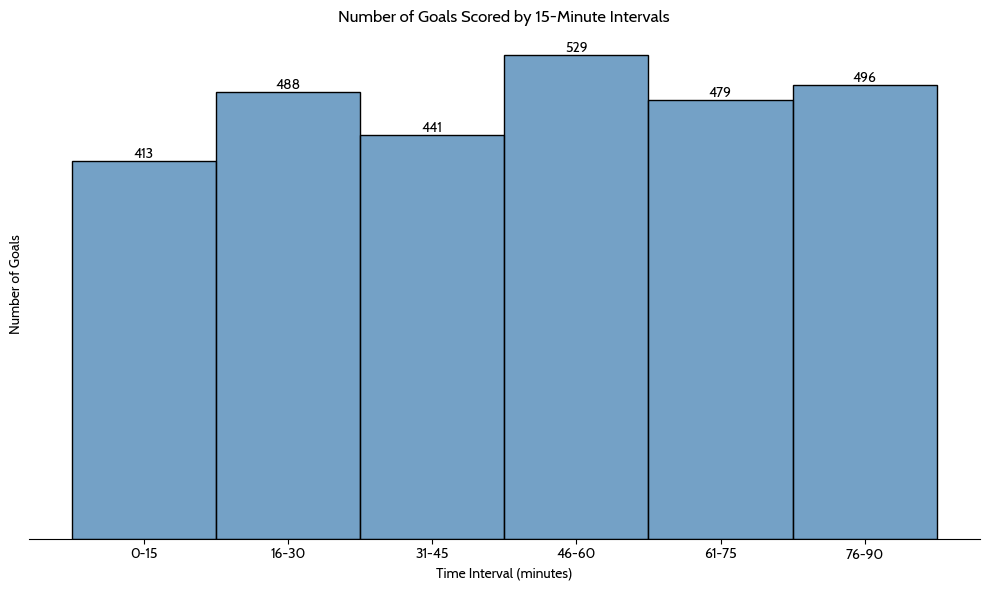

In [16]:
# Create bins for 15-minute intervals
bins = [0, 15, 30, 45, 60, 75, 90]
labels = ['0-15', '16-30', '31-45', '46-60', '61-75', '76-90']

# Bin the goal_minute_num into 15-minute intervals
dfr['15_goal_interval'] = pd.cut(dfr['goal_minute_num'], bins=bins, labels=labels, right=False)

# Create histogram using seaborn
plt.figure(figsize=(10, 6))
ax = sns.histplot(data=dfr, x='15_goal_interval', discrete=True, kde=False, color='steelblue')

# Get the bar patches
patches = [patch for patch in ax.patches]

# Add total count on top of each bar
for patch in patches:
    height = patch.get_height()
    ax.text(patch.get_x() + patch.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Remove yticks and labels
ax.set_yticks([])

plt.title('Number of Goals Scored by 15-Minute Intervals')
plt.xlabel('Time Interval (minutes)')
plt.ylabel('Number of Goals')
plt.tight_layout()
plt.show()

In [17]:
# Group by 'goal_interval' and count the number of goals
goal_counts = dfr.groupby('15_goal_interval',observed=True).size().reset_index(name='goal_count')
goal_counts

,15_goal_interval,goal_count
0,0-15,413
1,16-30,488
2,31-45,441
3,46-60,529
4,61-75,479
5,76-90,496


Most goals are scored in the 46-60 interval

C:\Users\Humphrey\AppData\Local\Temp\ipykernel_11380\3030198543.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfr['10_minute_interval'] = pd.cut(dfr['goal_minute_num'], bins=bins, labels=labels, right=False)


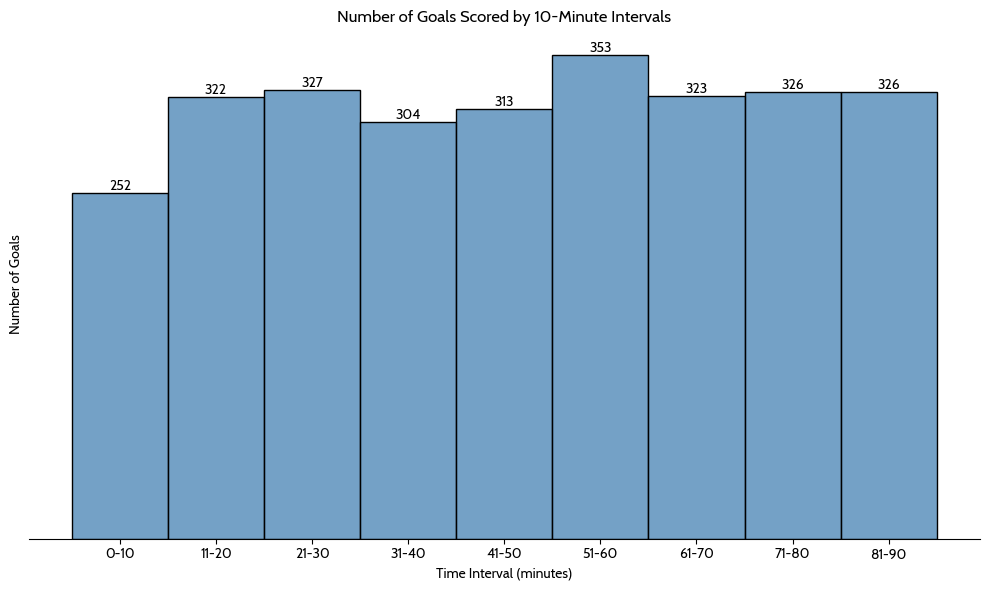

In [18]:
# Create bins for 10-minute intervals
bins = [0,10,20, 30, 40, 50, 60, 70,80, 90]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90']

# Bin the goal_minute_num into 10-minute intervals
dfr['10_minute_interval'] = pd.cut(dfr['goal_minute_num'], bins=bins, labels=labels, right=False)

# Create histogram using seaborn
plt.figure(figsize=(10, 6))
ax = sns.histplot(data=dfr, x='10_minute_interval', discrete=True, kde=False, color='steelblue')

# Get the bar patches
patches = [patch for patch in ax.patches]

# Add total count on top of each bar
for patch in patches:
    height = patch.get_height()
    ax.text(patch.get_x() + patch.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Remove yticks and labels
ax.set_yticks([])

plt.title('Number of Goals Scored by 10-Minute Intervals')
plt.xlabel('Time Interval (minutes)')
plt.ylabel('Number of Goals')
plt.tight_layout()
plt.show()

In [19]:
# Group by 'goal_interval' and count the number of goals
goal_counts10 = dfr.groupby('10_minute_interval',observed=True).size().reset_index(name='goal_count')
goal_counts10

,10_minute_interval,goal_count
0,0-10,252
1,11-20,322
2,21-30,327
3,31-40,304
4,41-50,313
5,51-60,353
6,61-70,323
7,71-80,326
8,81-90,326


Most goals are scored in the 51-60 interval

C:\Users\Humphrey\AppData\Local\Temp\ipykernel_11380\3931116000.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfr['5_minute_interval'] = pd.cut(dfr['goal_minute_num'], bins=bins, labels=labels, right=False)


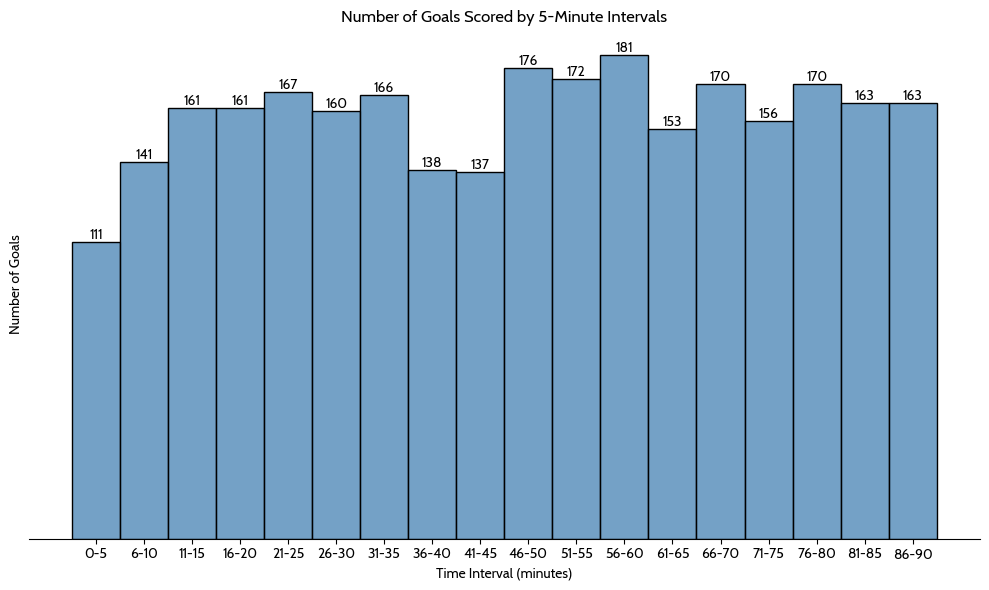

In [20]:
# Create bins for 5-minute intervals
bins = [0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90] 
labels = ['0-5','6-10','11-15','16-20','21-25','26-30','31-35','36-40','41-45','46-50','51-55','56-60','61-65','66-70','71-75','76-80','81-85','86-90']
# Bin the goal_minute_num into 5-minute intervals
dfr['5_minute_interval'] = pd.cut(dfr['goal_minute_num'], bins=bins, labels=labels, right=False)

# Create histogram using seaborn
plt.figure(figsize=(10, 6))
ax = sns.histplot(data=dfr, x='5_minute_interval', discrete=True, kde=False, color='steelblue')

# Get the bar patches
patches = [patch for patch in ax.patches]

# Add total count on top of each bar
for patch in patches:
    height = patch.get_height()
    ax.text(patch.get_x() + patch.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Remove yticks and labels
ax.set_yticks([])

plt.title('Number of Goals Scored by 5-Minute Intervals')
plt.xlabel('Time Interval (minutes)')
plt.ylabel('Number of Goals')
plt.tight_layout()
plt.show()


In [21]:
# Group by 'goal_interval' and count the number of goals
goal_counts5 = dfr.groupby('5_minute_interval',observed=True).size().reset_index(name='goal_count')
goal_counts5.sort_values(by='goal_count',ascending=False)

,5_minute_interval,goal_count
11,56-60,181
9,46-50,176
10,51-55,172
13,66-70,170
15,76-80,170
4,21-25,167
6,31-35,166
17,86-90,163
16,81-85,163
2,11-15,161


Most goals are in the 56-60th minute

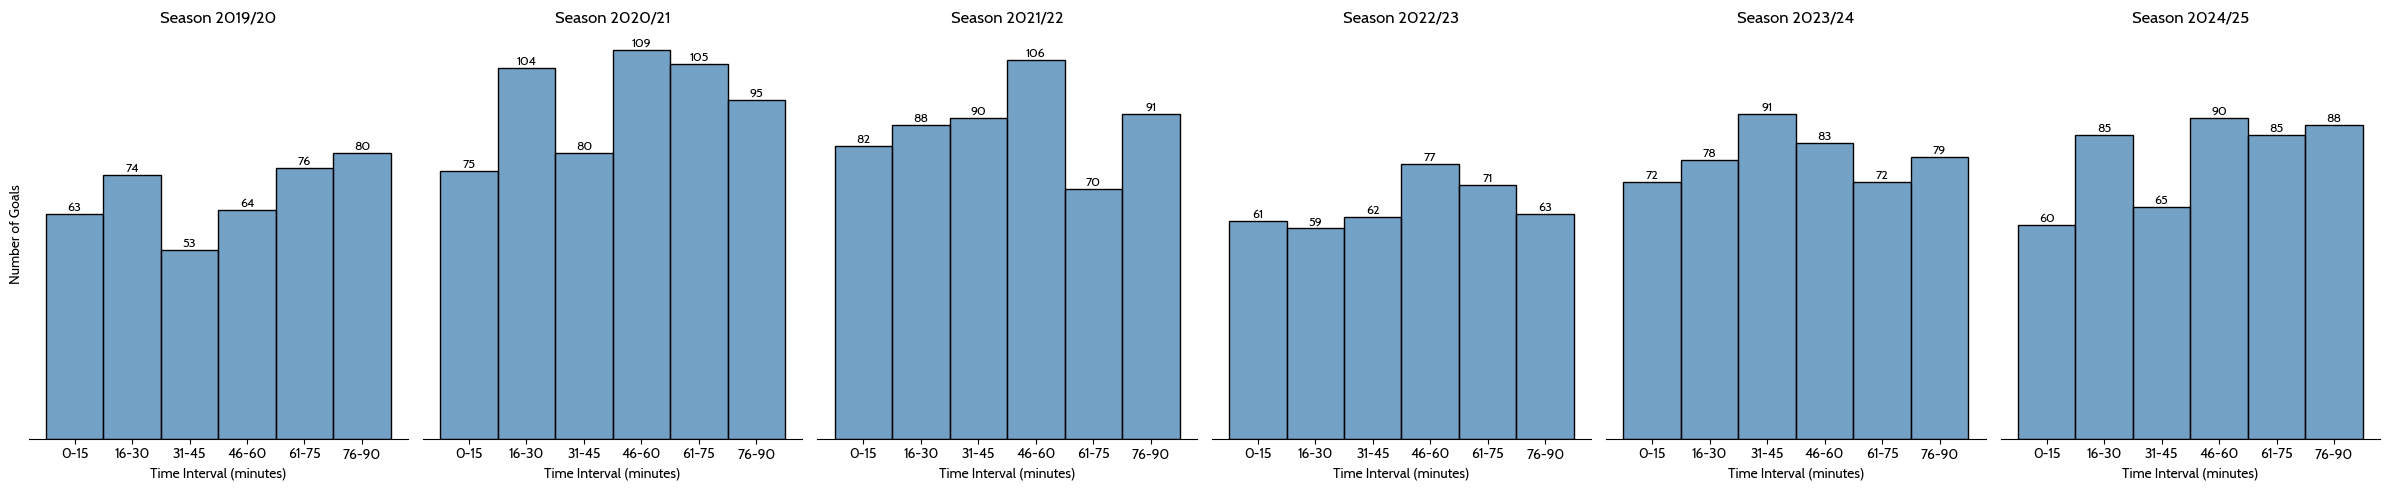

In [22]:
# Get unique seasons
seasons = dfr['season'].unique()
num_seasons = len(seasons)

# Create a figure with subplots (side by side)
fig, axes = plt.subplots(1, num_seasons, figsize=(4*num_seasons, 5), sharey=True)

# If only one season, axes is not an array
if num_seasons == 1:
    axes = [axes]

for idx, season in enumerate(sorted(seasons)):
    season_data = dfr[dfr['season'] == season]
    
    ax = axes[idx]
    
    # Create histogram
    ax = sns.histplot(data=season_data, x='15_goal_interval', discrete=True, kde=False, 
                      color='steelblue', ax=ax)
    
    # Get the bar patches
    patches = [patch for patch in ax.patches]
    
    # Add total count on top of each bar
    for patch in patches:
        height = patch.get_height()
        ax.text(patch.get_x() + patch.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9)
    
    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Remove yticks and labels for all except first
    if idx > 0:
        ax.set_yticks([])
    else:
        ax.set_ylabel('Number of Goals')
    
    ax.set_xlabel('Time Interval (minutes)')
    ax.set_title(f'Season {season}', fontweight='bold')

plt.tight_layout()
plt.show()

Saved.


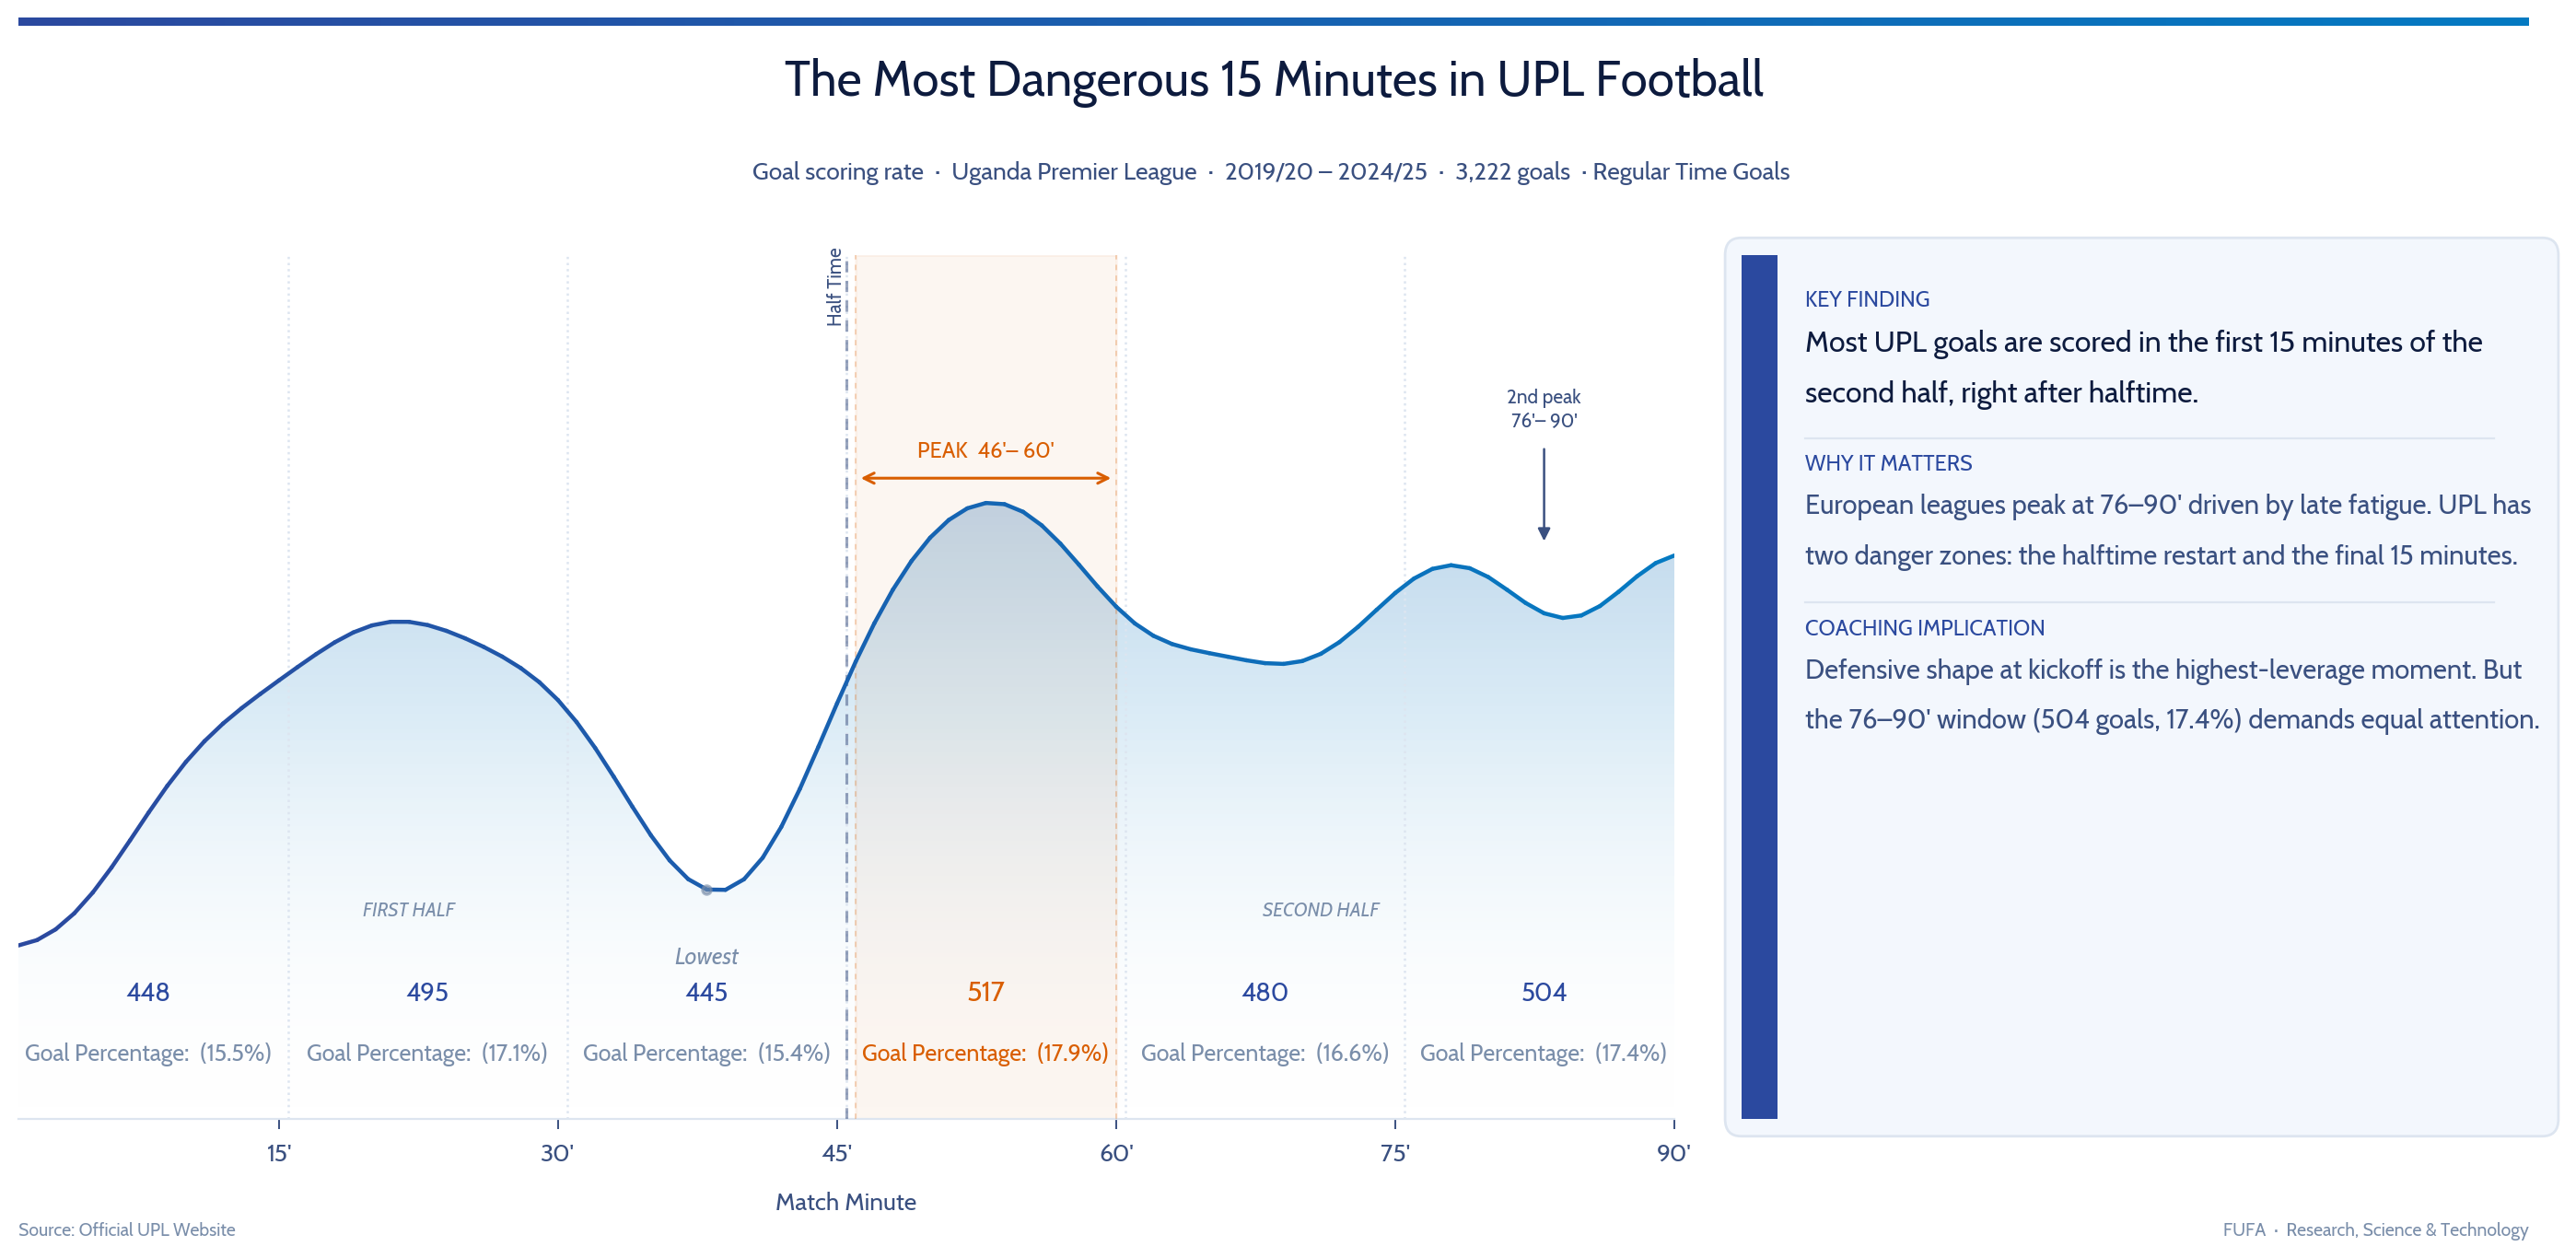

In [23]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
from matplotlib.patches import PathPatch, FancyBboxPatch, Rectangle
from matplotlib.path import Path
from matplotlib.collections import LineCollection
from scipy.ndimage import gaussian_filter1d

matplotlib.rcParams['font.family'] = 'Cabin'  # fallback if Cabin not installed

# ── Data ─────────────────────────────────────────────────────────────────────
raw = dfr['goal_minute_num'].value_counts().reindex(range(1, 91), fill_value=0).values.astype(float)
windows = [(1,15),(16,30),(31,45),(46,60),(61,75),(76,90)]

window_goals_target = [448, 495, 445, 517, 480, 504]
window_goals = [int(raw[a-1:b].sum()) for a, b in windows]

smoothed     = gaussian_filter1d(raw, sigma=4.0)
minutes      = np.arange(1, 91)
window_goals = window_goals_target
window_pct   = [round(g / sum(window_goals) * 100, 1) for g in window_goals]
window_mids  = [8, 23, 38, 53, 68, 83]

# ── Palette ───────────────────────────────────────────────────────────────────
FUFA_DARK  = "#2b499f"
FUFA_LIGHT = "#047ac2"
ORANGE     = "#D95E00"
ORANGE2    = "#8B3A00"   # second peak annotation — darker to differentiate
BG         = "#FFFFFF"
PANEL_BG   = "#F3F7FD"
GRID       = "#DDE5F0"
TEXT_DARK  = "#0D1B3E"
TEXT_MID   = "#3A5080"
TEXT_LIGHT = "#7A8EAA"

y_floor = smoothed.min() - 2.8
y_ceil  = smoothed.max() + 1.0

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14.5, 7.0), facecolor=BG, dpi=200)

ax     = fig.add_axes([0.03, 0.13, 0.62, 0.67])
ax_ann = fig.add_axes([0.675, 0.13, 0.30, 0.67])
ax_hdr = fig.add_axes([0.03, 0.82, 0.94, 0.14])

for a in [ax, ax_ann, ax_hdr]:
    a.set_facecolor(BG)
    a.set_axis_off()
ax.set_axis_on()

# ── Gradient top bar ──────────────────────────────────────────────────────────
tb = fig.add_axes([0.03, 0.978, 0.94, 0.006])
tb.imshow(np.linspace(0, 1, 256).reshape(1, 256), aspect='auto',
    cmap=mcolors.LinearSegmentedColormap.from_list("b", [FUFA_DARK, FUFA_LIGHT]))
tb.set_axis_off()

# ── Header ────────────────────────────────────────────────────────────────────
ax_hdr.text(0.5, 0.95,
    "The Most Dangerous 15 Minutes in UPL Football",
    fontsize=19, fontweight='bold', color=TEXT_DARK,
    ha='center', va='top', transform=ax_hdr.transAxes)
ax_hdr.text(0.5, 0.38,
    "Goal scoring rate  ·  Uganda Premier League  ·  2019/20 – 2024/25  ·  3,222 goals  · Regular Time Goals ",
    fontsize=9.5, color=TEXT_MID, ha='center', va='top',
    transform=ax_hdr.transAxes)

# ── Gradient fill under curve ─────────────────────────────────────────────────
cmap_f = mcolors.LinearSegmentedColormap.from_list("f", [
    (0.0, (*mcolors.to_rgb(BG),         0.0)),
    (0.4, (*mcolors.to_rgb(FUFA_LIGHT), 0.14)),
    (1.0, (*mcolors.to_rgb(FUFA_DARK),  0.48))], N=256)
img = ax.imshow(np.linspace(0, 1, 256).reshape(256, 1), aspect='auto',
    cmap=cmap_f, extent=[1, 90, y_floor, y_ceil + 5], origin='lower', zorder=1)
verts = ([(minutes[0], y_floor)] + list(zip(minutes, smoothed))
         + [(minutes[-1], y_floor), (minutes[0], y_floor)])
codes = [Path.MOVETO] + [Path.LINETO] * 90 + [Path.LINETO, Path.CLOSEPOLY]
img.set_clip_path(PathPatch(Path(verts, codes), transform=ax.transData))

# ── Gradient line ─────────────────────────────────────────────────────────────
pts  = np.array([minutes, smoothed]).T.reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc   = LineCollection(segs,
    cmap=mcolors.LinearSegmentedColormap.from_list("ln", [FUFA_DARK, FUFA_LIGHT]),
    norm=plt.Normalize(1, 90), linewidth=1.6,
    capstyle='round', joinstyle='round', zorder=5)
lc.set_array(minutes[:-1].astype(float))
ax.add_collection(lc)

# ── Window dividers ───────────────────────────────────────────────────────────
for x in [15.5, 30.5, 45.5, 60.5, 75.5]:
    ax.axvline(x, color=GRID, linewidth=0.9, linestyle=':', zorder=3)

# ── Halftime marker ───────────────────────────────────────────────────────────
ax.axvline(45.5, color=TEXT_MID, linewidth=1.1,
    linestyle=(0, (4, 3)), alpha=0.5, zorder=4)
ax.text(45.5, y_ceil + 2.5, "Half Time", color=TEXT_MID,
    fontsize=7.5, ha='center', va='bottom', rotation=90,
    rotation_mode='anchor', zorder=6)

# ── Peak window (46-60) — lighter border ──────────────────────────────────────
ax.axvspan(46, 60, color=ORANGE, alpha=0.055, zorder=2)
# FIX: reduced alpha from 0.6 → 0.25 so dashes don't compete with the curve
ax.axvline(46, color=ORANGE, linewidth=0.7, linestyle=(0, (3, 3)), alpha=0.25, zorder=4)
ax.axvline(60, color=ORANGE, linewidth=0.7, linestyle=(0, (3, 3)), alpha=0.25, zorder=4)
bkt_y = smoothed.max() + 0.4
ax.annotate("", xy=(60, bkt_y), xytext=(46, bkt_y),
    arrowprops=dict(arrowstyle="<->", color=ORANGE, lw=1.1), zorder=6)
ax.text(53, bkt_y + 0.25, "PEAK  46'– 60'",
    color=ORANGE, fontsize=8.5, ha='center', va='bottom',
    fontweight='bold', zorder=6)

# ── Second peak annotation (76-90) ────────────────────────────────────────────
# FIX: call out the near-identical second peak so readers don't miss it
peak2_x = 83
peak2_y = smoothed[75:].max()
ax.annotate("",
    xy=(peak2_x, peak2_y + 0.15),
    xytext=(peak2_x, peak2_y + 1.8),
    arrowprops=dict(arrowstyle="-|>", color=TEXT_MID, lw=0.9), zorder=6)
ax.text(peak2_x, peak2_y + 2.0, "2nd peak\n76'– 90'",
    color=TEXT_MID, fontsize=7.5, ha='center', va='bottom',
    linespacing=1.3, zorder=6)

# ── Trough annotation at ~min 42-45 ──────────────────────────────────────────
# FIX: mark the lowest window — the contrast between trough and peak tells the story
trough_x = 38  # 31-45 window midpoint, visually near the dip
trough_y = smoothed[30:45].min()
ax.text(trough_x, trough_y - 0.9, "Lowest",
    color=TEXT_LIGHT, fontsize=9, ha='center', va='top',
    fontstyle='italic', zorder=6)
ax.plot(trough_x, trough_y, 'o', color=TEXT_LIGHT, markersize=3.5,
    alpha=0.6, zorder=6)

# ── Per-window goal counts at base ────────────────────────────────────────────
for i, (mid, goals, pct) in enumerate(zip(window_mids, window_goals, window_pct)):
    pk = (i == 3)
    nc = ORANGE if pk else FUFA_DARK
    sc = ORANGE if pk else TEXT_LIGHT
    ax.text(mid, y_floor + 1.8, f"{goals}",
        color=nc, fontsize=11 if pk else 10,
        ha='center', va='bottom', fontweight='bold', zorder=6)
    ax.text(mid, y_floor + 0.85, f"Goal Percentage:  ({pct}%)",
        color=sc, fontsize=9, ha='center', va='bottom', zorder=6)

# ── Half labels — FIX: raised to sit just above the number labels ─────────────
for x, lbl in [(22, "FIRST HALF"), (71, "SECOND HALF")]:
    ax.text(x, y_floor + 3.2, lbl, color=TEXT_LIGHT, fontsize=7.5,
        ha='center', va='bottom', fontstyle='italic', zorder=6)

# ── Axes styling ──────────────────────────────────────────────────────────────
ax.set_xlim(1, 90)
ax.set_ylim(y_floor, y_ceil + 3)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.tick_params(axis='x', colors=TEXT_MID, labelsize=9.5, length=4, width=0.7, pad=5)
ax.tick_params(axis='y', left=False, labelleft=False)
ax.set_xticks([15, 30, 45, 60, 75, 90])
ax.set_xticklabels(["15'", "30'", "45'", "60'", "75'", "90'"])
ax.set_xlabel("Match Minute", color=TEXT_MID, fontsize=9.5, labelpad=10)

# ── Annotation panel ──────────────────────────────────────────────────────────
ax_ann.set_xlim(0, 1)
ax_ann.set_ylim(0, 1)

ax_ann.add_patch(FancyBboxPatch((0, 0), 1, 1,
    boxstyle="round,pad=0.02", lw=1.0,
    edgecolor=GRID, facecolor=PANEL_BG, zorder=0, clip_on=False,
    transform=ax_ann.transAxes))
ax_ann.add_patch(Rectangle((0, 0), 0.045, 1,
    lw=0, facecolor=FUFA_DARK, zorder=1, clip_on=False,
    transform=ax_ann.transAxes))

T        = ax_ann.transAxes
LH_LABEL = 0.030
LH_BODY  = 0.058
GAP      = 0.016
SEP      = 0.028

def write_block(y_top, label, body_lines, body_color=TEXT_MID, body_size=10.5, body_weight='normal'):
    ax_ann.text(0.08, y_top, label,
        color=FUFA_DARK, fontsize=8.5, fontweight='bold',
        va='top', ha='left', transform=T, zorder=5)
    y = y_top - LH_LABEL - GAP
    for line in body_lines:
        ax_ann.text(0.08, y, line,
            color=body_color, fontsize=body_size, fontweight=body_weight,
            va='top', ha='left', transform=T, zorder=5)
        y -= LH_BODY
    return y - SEP

y = 0.96

# KEY FINDING — FIX: rewrapped so phrases break naturally
y = write_block(y, "KEY FINDING", [
    "Most UPL goals are scored in the first 15 minutes of the",
    "second half, right after halftime.",
], body_color=TEXT_DARK, body_size=11.5, body_weight='semibold')

ax_ann.plot([0.08, 0.94], [y + SEP - 0.01, y + SEP - 0.01],
    color=GRID, lw=0.8, transform=T, clip_on=False)

# WHY IT MATTERS — FIX: now acknowledges the second peak at 76-90
y = write_block(y, "WHY IT MATTERS", [
    "European leagues peak at 76–90' driven by late fatigue. UPL has",
    "two danger zones: the halftime restart and the final 15 minutes.",
])

ax_ann.plot([0.08, 0.94], [y + SEP - 0.01, y + SEP - 0.01],
    color=GRID, lw=0.8, transform=T, clip_on=False)

# COACHING IMPLICATION — FIX: references the 504 goals in 76-90 to make second peak concrete
y = write_block(y, "COACHING IMPLICATION", [
    "Defensive shape at kickoff is the highest-leverage moment. But",
    "the 76–90' window (504 goals, 17.4%) demands equal attention.",
])

ax_ann.set_axis_off()

# ── Footer ────────────────────────────────────────────────────────────────────
fig.text(0.03, 0.04,
    "Source: Official UPL Website",
    fontsize=7, color=TEXT_LIGHT)
fig.text(0.97, 0.04, "FUFA  ·  Research, Science & Technology",
    fontsize=7, color=TEXT_LIGHT, ha='right')

# plt.savefig("/mnt/user-data/outputs/goal_timing_final.png", dpi=200, bbox_inches='tight', facecolor=BG)
print("Saved.")

### Goal Quality Ratio

In [24]:
def calculate_gqr(dfr: pd.DataFrame) -> float:
    """
    Calculate Goal Quality Ratio (GQR).

    GQR = (Open Play Goals) / (Total Goals)

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe containing 'goal_type'.

    Returns
    -------
    float
        The GQR value. Returns 0.0 if no goals.
    """
    total_goals = len(dfr)
    if total_goals == 0:
        return 0.0

    # Define non-open play types
    non_open_play = ['Penalty', 'Own Goal']
    
    # Count open play goals
    open_play_count = len(dfr[~dfr["goal_type"].isin(non_open_play)])
    
    return open_play_count / total_goals

In [25]:
calculate_gqr(dfr)

0.887203166226913

In [26]:
for season in dfr['season'].unique():
    season_df = dfr[dfr['season'] == season]
    gqr = calculate_gqr(season_df)
    print(f"Season {season}: GQR = {gqr:.4f}, Total Goals = {len(season_df)}")

Season 2019/20: GQR = 0.8764, Total Goals = 437
Season 2020/21: GQR = 0.8876, Total Goals = 596
Season 2021/22: GQR = 0.8668, Total Goals = 563
Season 2022/23: GQR = 0.8965, Total Goals = 425
Season 2023/24: GQR = 0.9030, Total Goals = 505
Season 2024/25: GQR = 0.8953, Total Goals = 506


### Goal Timing Shift Index(GTSI)

In [27]:
def calculate_gtsi(dfr: pd.DataFrame) -> float:
    """
    Calculate Goal Timing Shift Index (GTSI).

    GTSI = ratio of goals in Decisive Window (76-90+) vs Peak Focus Window (16-30).

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe containing 'goal_minute_num'.

    Returns
    -------
    float
        The GTSI value. Returns NaN if zero goals in Peak Focus Window.
    """
    # Decisive Window: 76-90+ (>= 76)
    decisive_goals = len(dfr[dfr["goal_minute_num"] >= 76])
    
    # Peak Focus Window: 16-30 (inclusive)
    peak_focus_goals = len(dfr[(dfr["goal_minute_num"] >= 16) & (dfr["goal_minute_num"] <= 30)])
    
    if peak_focus_goals == 0:
        return np.nan
        
    return decisive_goals / peak_focus_goals

In [28]:
for season in dfr['season'].unique():
    season_df = dfr[dfr['season'] == season]
    gtsi = calculate_gtsi(season_df)
    print(f"Season {season}: GTSI = {gtsi:.4f}")

Season 2019/20: GTSI = 1.1857
Season 2020/21: GTSI = 0.9417
Season 2021/22: GTSI = 0.9780
Season 2022/23: GTSI = 1.0667
Season 2023/24: GTSI = 1.0633
Season 2024/25: GTSI = 0.9457


### Seasonal Trends: GQR & GTSI

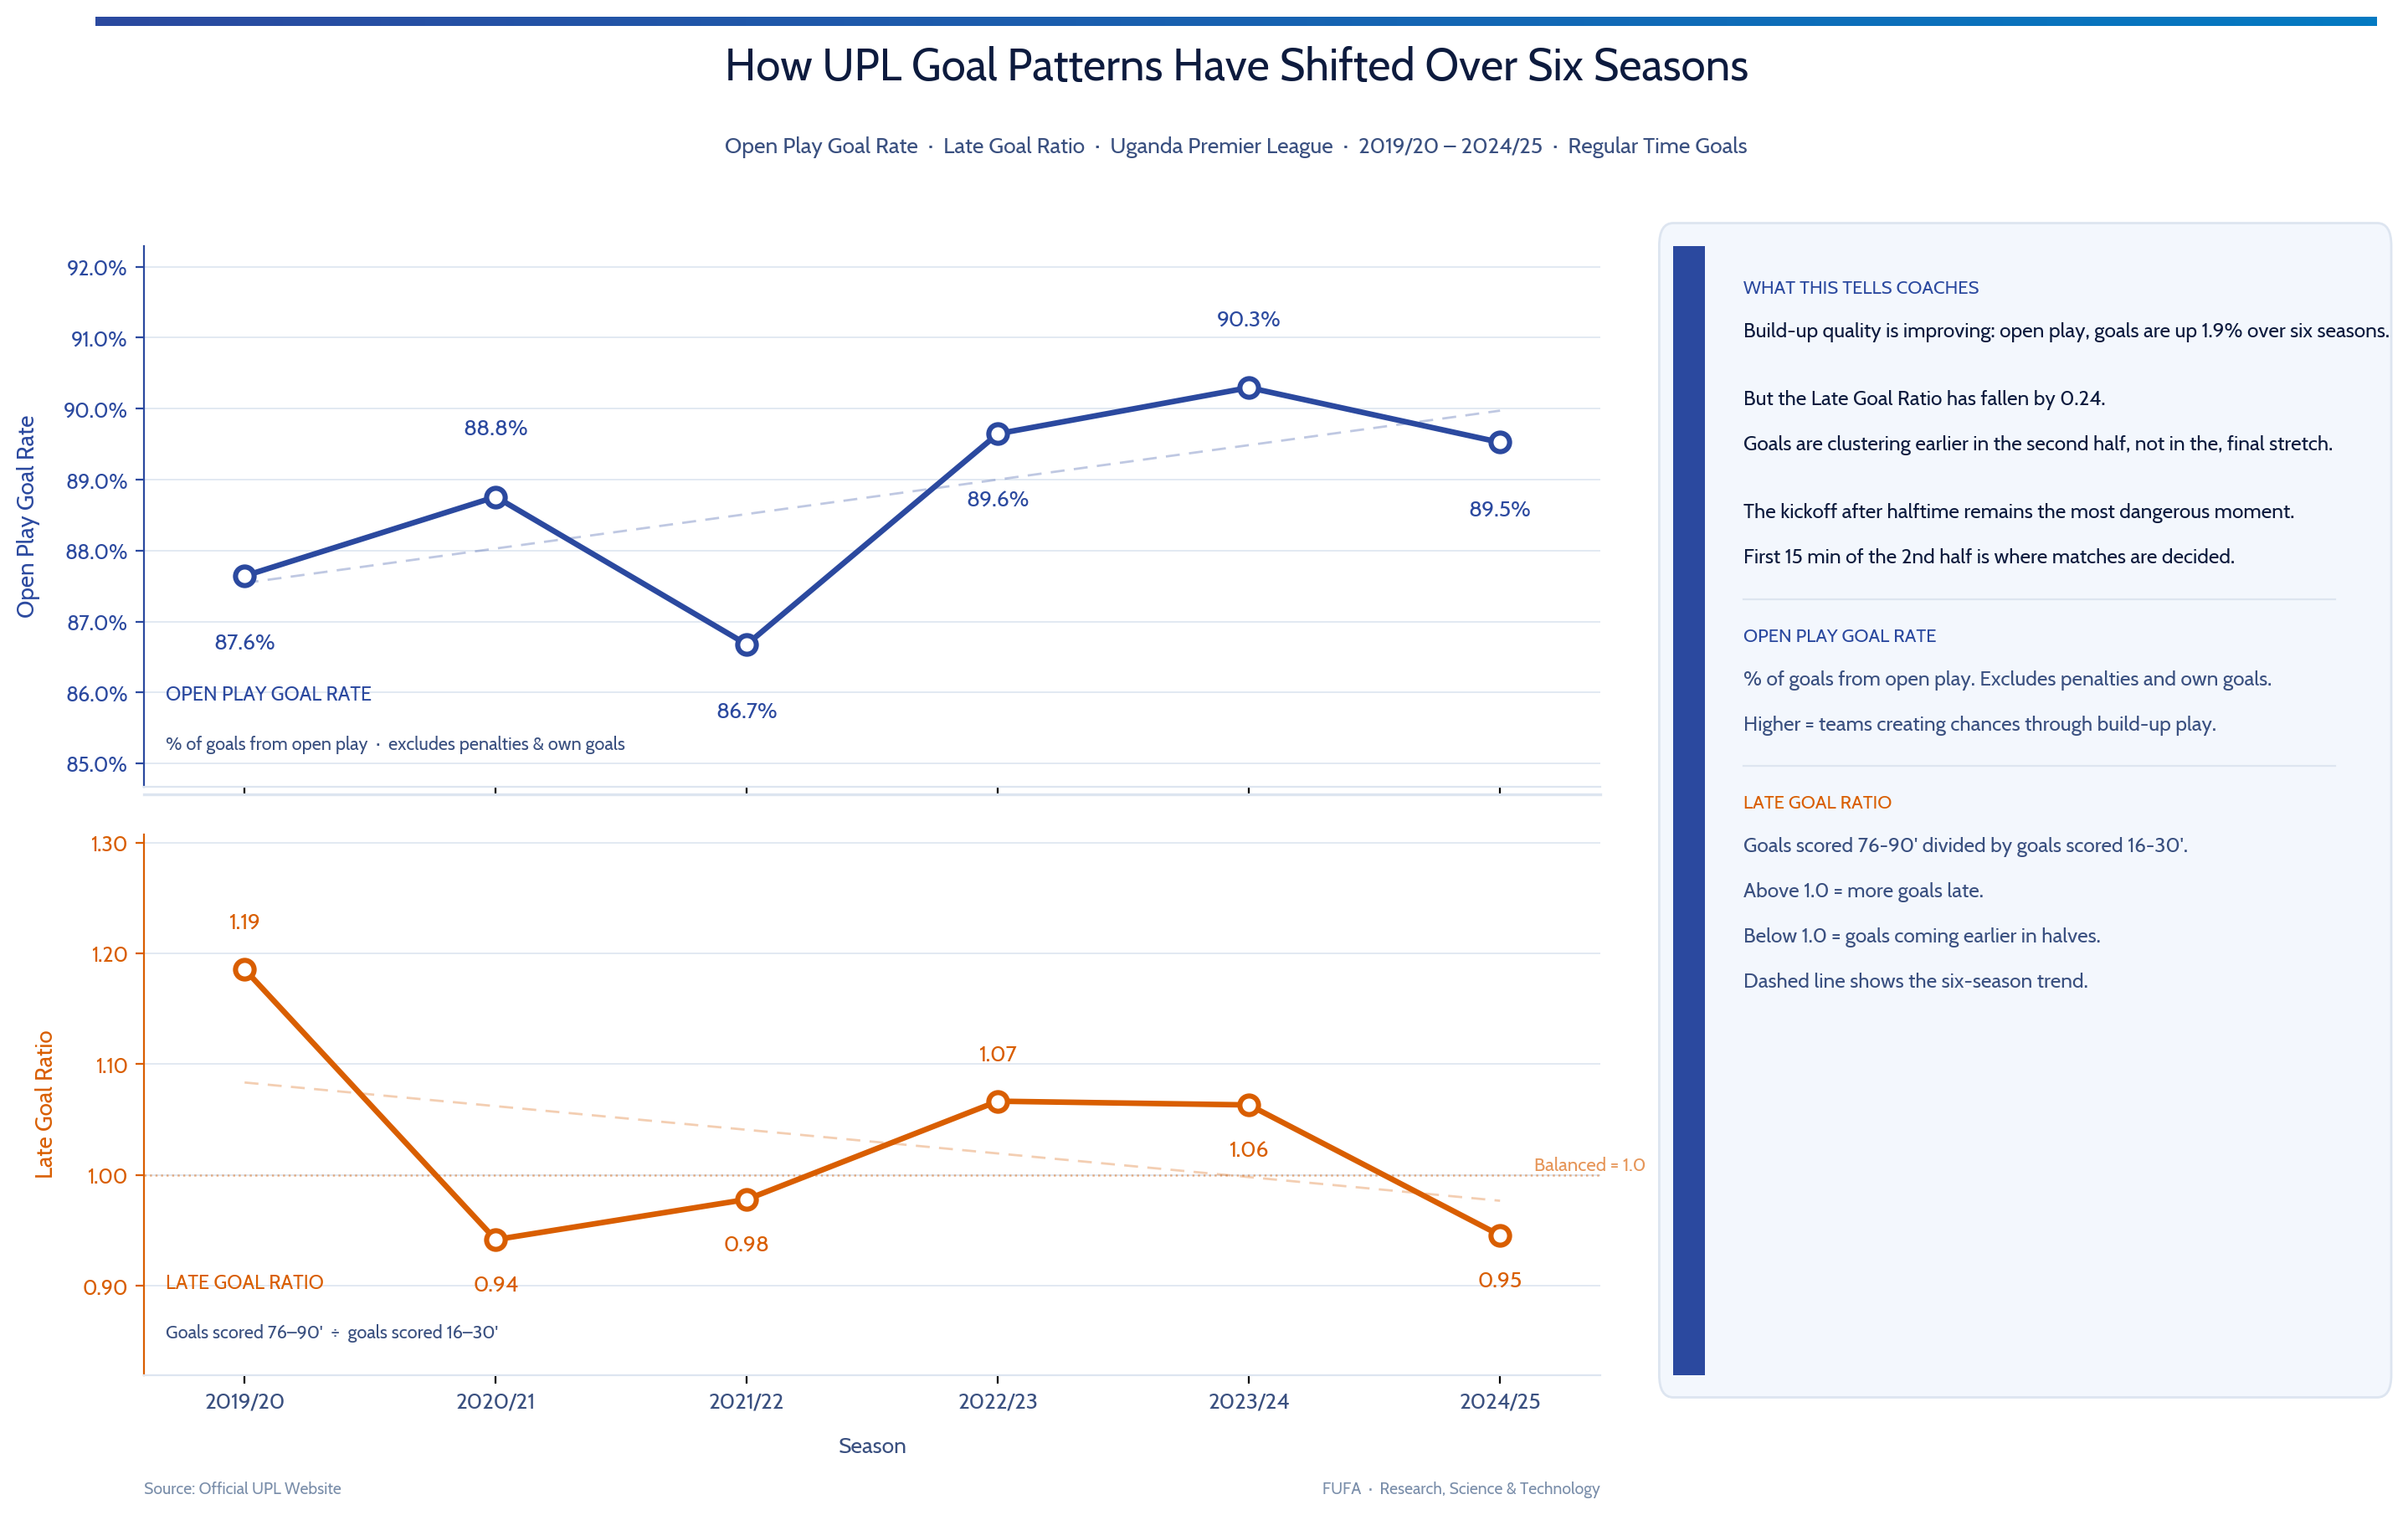

In [31]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import FancyBboxPatch, Rectangle

matplotlib.rcParams["font.family"] = "Cabin"

# ── Data ──────────────────────────────────────────────────────────────────────
seasons = sorted(dfr["season"].unique())
gqr_vals, gtsi_vals = [], []
for s in seasons:
    sdf = dfr[dfr["season"] == s]
    gqr_vals.append(calculate_gqr(sdf))
    gtsi_vals.append(calculate_gtsi(sdf))

gqr_arr  = np.array(gqr_vals)
gtsi_arr = np.array(gtsi_vals)
x        = np.arange(len(seasons))

# ── Palette ───────────────────────────────────────────────────────────────────
FUFA_DARK  = "#2b499f"
FUFA_LIGHT = "#047ac2"
ORANGE     = "#D95E00"
BG         = "#FFFFFF"
PANEL_BG   = "#F3F7FD"
GRID       = "#DDE5F0"
TEXT_DARK  = "#0D1B3E"
TEXT_MID   = "#3A5080"
TEXT_LIGHT = "#7A8EAA"

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14.5, 9.5), facecolor=BG, dpi=200)

ax_top = fig.add_axes([0.05, 0.50, 0.60, 0.34])  # GQR chart
ax_bot = fig.add_axes([0.05, 0.13, 0.60, 0.34])  # GTSI chart
ax_ann = fig.add_axes([0.68, 0.13, 0.29, 0.71])  # annotation panel
ax_hdr = fig.add_axes([0.03, 0.88, 0.94, 0.09])  # header

for a in [ax_ann, ax_hdr]:
    a.set_facecolor(BG)
    a.set_axis_off()

# ── Gradient top bar ──────────────────────────────────────────────────────────
tb = fig.add_axes([0.03, 0.978, 0.94, 0.006])
tb.imshow(
    np.linspace(0, 1, 256).reshape(1, 256), aspect="auto",
    cmap=mcolors.LinearSegmentedColormap.from_list("b2", [FUFA_DARK, FUFA_LIGHT]),
)
tb.set_axis_off()

# ── Header ────────────────────────────────────────────────────────────────────
ax_hdr.text(
    0.5, 0.95, "How UPL Goal Patterns Have Shifted Over Six Seasons",
    fontsize=19, fontweight="bold", color=TEXT_DARK,
    ha="center", va="top", transform=ax_hdr.transAxes,
)
ax_hdr.text(
    0.5, 0.32,
    "Open Play Goal Rate  ·  Late Goal Ratio  ·  Uganda Premier League"
    "  ·  2019/20 – 2024/25  ·  Regular Time Goals",
    fontsize=9.5, color=TEXT_MID, ha="center", va="top",
    transform=ax_hdr.transAxes,
)

# ── Smart label placement ─────────────────────────────────────────────────────
def label_position(arr, i):
    """Return (va, sign): place label above local peaks, below local troughs."""
    lo = arr[i - 1] if i > 0 else arr[i]
    hi = arr[i + 1] if i < len(arr) - 1 else arr[i]
    if arr[i] >= max(lo, hi):
        return "bottom", 1
    return "top", -1

# ── Generic chart drawer ──────────────────────────────────────────────────────
def draw_chart(
    ax, x, arr, color, ylabel, fmt_fn,
    hide_xticklabels=False,
    ref_line=None, ref_label=None,
    inner_title=None, inner_subtitle=None,
):
    pad = max((arr.max() - arr.min()) * 0.50, 0.02)
    ax.set_facecolor(BG)
    ax.set_ylim(arr.min() - pad, arr.max() + pad)
    ax.set_xlim(-0.4, len(x) - 0.6)
    ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=1)
    ax.set_axisbelow(True)

    # Reference line (GTSI only)
    if ref_line is not None:
        ax.axhline(ref_line, color=color, linewidth=0.9, linestyle=":", alpha=0.45, zorder=2)
        ax.text(
            len(x) - 0.42, ref_line,
            ref_label, color=color,
            fontsize=8, va="bottom", ha="right", alpha=0.65,
        )

    # Trend line
    z = np.polyfit(x, arr, 1)
    ax.plot(x, np.poly1d(z)(x), color=color, linewidth=1.0,
            linestyle=(0, (6, 4)), alpha=0.30, zorder=3)

    # Main line + markers
    ax.plot(
        x, arr, color=color, linewidth=2.4,
        marker="o", markersize=8,
        markerfacecolor=BG, markeredgewidth=2.2, markeredgecolor=color,
        zorder=6,
    )

    # Data labels -- offset scaled to axis range to prevent overlap
    offset = max((arr.max() - arr.min()) * 0.13, 0.008)
    for i, (xi, yi) in enumerate(zip(x, arr)):
        va, sign = label_position(arr, i)
        ax.text(
            xi, yi + sign * offset, fmt_fn(yi),
            color=color, fontsize=9.5, fontweight="bold",
            ha="center", va=va, zorder=7,
        )

    # Axes
    ax.set_ylabel(ylabel, color=color, fontsize=10, labelpad=10)
    ax.tick_params(axis="y", colors=color, labelsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt_fn(v)))
    ax.set_xticks(x)

    if hide_xticklabels:
        ax.set_xticklabels([])
        ax.set_xlabel("")
    else:
        ax.set_xticklabels(seasons, fontsize=9.5, color=TEXT_MID)
        ax.set_xlabel("Season", color=TEXT_MID, fontsize=9.5, labelpad=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(color)
    ax.spines["bottom"].set_color(GRID)

    # Inner label (bottom-left of chart to avoid data label collisions)
    if inner_title:
        ax.text(
            0.015, 0.15, inner_title,
            color=color, fontsize=8.5, fontweight="bold",
            va="bottom", transform=ax.transAxes,
        )
    if inner_subtitle:
        ax.text(
            0.015, 0.06, inner_subtitle,
            color=TEXT_MID, fontsize=7.8,
            va="bottom", transform=ax.transAxes,
        )

# ── GQR chart ─────────────────────────────────────────────────────────────────
draw_chart(
    ax_top, x, gqr_arr, FUFA_DARK,
    ylabel="Open Play Goal Rate",
    fmt_fn=lambda v: f"{v:.1%}",
    hide_xticklabels=True,
    inner_title="OPEN PLAY GOAL RATE",
    inner_subtitle="% of goals from open play  ·  excludes penalties & own goals",
)

# ── GTSI chart ────────────────────────────────────────────────────────────────
draw_chart(
    ax_bot, x, gtsi_arr, ORANGE,
    ylabel="Late Goal Ratio",
    fmt_fn=lambda v: f"{v:.2f}",
    ref_line=1.0, ref_label="Balanced = 1.0",
    inner_title="LATE GOAL RATIO",
    inner_subtitle="Goals scored 76–90'  ÷  goals scored 16–30'",
)

# ── Divider between charts ────────────────────────────────────────────────────
fig.add_artist(
    plt.Line2D([0.05, 0.65], [0.495, 0.495],
               transform=fig.transFigure, color=GRID, linewidth=1.2)
)

# ── Annotation panel ──────────────────────────────────────────────────────────
ax_ann.set_xlim(0, 1)
ax_ann.set_ylim(0, 1)

ax_ann.add_patch(FancyBboxPatch(
    (0, 0), 1, 1, boxstyle="round,pad=0.02", lw=1.0,
    edgecolor=GRID, facecolor=PANEL_BG, zorder=0,
    clip_on=False, transform=ax_ann.transAxes,
))
ax_ann.add_patch(Rectangle(
    (0, 0), 0.045, 1, lw=0, facecolor=FUFA_DARK, zorder=1,
    clip_on=False, transform=ax_ann.transAxes,
))

T = ax_ann.transAxes
LH  = 0.040  # line height per body row (tight)
GAP = 0.010  # gap between section label and first body line
SEP = 0.030  # gap after a block before next section label
PGP = 0.020  # paragraph gap within a block (replaces empty "" lines)

def sep_line(y):
    ax_ann.plot([0.10, 0.94], [y, y], color=GRID, lw=0.8,
                transform=T, clip_on=False)

def write_block(y_top, label, body_paragraphs,
                label_color=FUFA_DARK, body_color=TEXT_MID,
                body_size=8.8, body_weight="normal"):
    """body_paragraphs: list of lists of strings. Each inner list is a paragraph."""
    ax_ann.text(0.10, y_top, label,
                color=label_color, fontsize=8.0, fontweight="bold",
                va="top", ha="left", transform=T, zorder=5)
    y = y_top - 0.028 - GAP
    first_para = True
    for para in body_paragraphs:
        if not first_para:
            y -= PGP
        for line in para:
            ax_ann.text(0.10, y, line,
                        color=body_color, fontsize=body_size, fontweight=body_weight,
                        va="top", ha="left", transform=T, zorder=5)
            y -= LH
        first_para = False
    return y - SEP

# ── Compute key values for insight text ───────────────────────────────────────
gqr_delta  = gqr_arr[-1] - gqr_arr[0]
gtsi_start = gtsi_arr[0]
gtsi_end   = gtsi_arr[-1]
gtsi_delta = abs(gtsi_end - gtsi_start)
gtsi_dir   = "fallen" if gtsi_end < gtsi_start else "risen"

y = 0.97

y = write_block(y, "WHAT THIS TELLS COACHES",
    [
        [f"Build-up quality is improving: open play, goals are up " 
        f"{abs(gqr_delta):.1%} over six seasons."],
        [f"But the Late Goal Ratio has {gtsi_dir} by {gtsi_delta:.2f}.",
         "Goals are clustering earlier in the second half, not in the, final stretch."],
        ["The kickoff after halftime remains the most dangerous moment. ",
         "First 15 min of the 2nd half is where matches are decided.",
         ],
    ],
    label_color=FUFA_DARK, body_color=TEXT_DARK,
    body_size=8.8, body_weight="semibold",
)

sep_line(y + SEP - 0.005)

y = write_block(y, "OPEN PLAY GOAL RATE",
    [["% of goals from open play. Excludes penalties and own goals.",
      "Higher = teams creating chances through build-up play.",
      ]],
    label_color=FUFA_DARK,
)

sep_line(y + SEP - 0.005)

y = write_block(y, "LATE GOAL RATIO",
    [["Goals scored 76-90' divided by goals scored 16-30'. ",
      "Above 1.0 = more goals late.",
      "Below 1.0 = goals coming earlier in halves.",
      "Dashed line shows the six-season trend."]],
    label_color=ORANGE,
)

ax_ann.set_axis_off()

# ── Footer (both items left of annotation panel) ──────────────────────────────
fig.text(0.05, 0.055, "Source: Official UPL Website", fontsize=7, color=TEXT_LIGHT)
fig.text(0.65, 0.055, "FUFA  ·  Research, Science & Technology",
         fontsize=7, color=TEXT_LIGHT, ha="right")

plt.savefig("gqr_gtsi_trends.png", dpi=200, bbox_inches="tight", facecolor=BG)
plt.show()